# 04 — Feature Engineering & Exploratory Analysis

Generates behavioral, time-based, and geographic features from the cleaned
dataset, then explores how they differ between fraudulent and legitimate transactions.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv(r'C:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/cleaned_transactions.csv')

In [44]:
df['timestamp'] = pd.to_datetime(df['timestamp'])



In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10622 entries, 0 to 10621
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   transaction_id             10622 non-null  str           
 1   customer_id                10622 non-null  str           
 2   timestamp                  10622 non-null  datetime64[us]
 3   home_country               10622 non-null  str           
 4   source_currency            10622 non-null  str           
 5   dest_currency              10622 non-null  str           
 6   channel                    10622 non-null  str           
 7   amount_src                 10622 non-null  float64       
 8   amount_usd                 10622 non-null  float64       
 9   fee                        10622 non-null  float64       
 10  exchange_rate_src_to_dest  10622 non-null  float64       
 11  device_id                  10622 non-null  str           
 12  new_device     

In [46]:
df.dropna(inplace=True)

In [47]:
# explain this lines


df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['is_weekend'] = df['timestamp'].dt.weekday >= 5
df['is_night'] = df['hour_of_day'].isin([0,1,2,3,4,5])
df[['hour_of_day', 'day_of_week', 'is_weekend', 'is_night']].head()

,hour_of_day,day_of_week,is_weekend,is_night
0,18,Monday,False,False
1,20,Monday,False,False
2,23,Monday,False,False
3,1,Tuesday,False,True
4,9,Tuesday,False,False


In [48]:
df['hour_of_day'] = df['timestamp'].dt.hour

In [49]:
df['day_of_week'] = df['timestamp'].dt.day_name()

In [50]:
df['is_weekend'] = df['timestamp'].dt.weekday >= 5

In [51]:
df['is_night'] = df['hour_of_day'].isin([0,1,2,3,4,5])

In [52]:
df[['hour_of_day', 'day_of_week', 'is_weekend', 'is_night']].head()

,hour_of_day,day_of_week,is_weekend,is_night
0,18,Monday,False,False
1,20,Monday,False,False
2,23,Monday,False,False
3,1,Tuesday,False,True
4,9,Tuesday,False,False


In [53]:
df['corridor'] = df['source_currency'] + '_to_' + df['dest_currency']


In [54]:
df['corridor'].value_counts()

corridor
USD_to_NGN    960
USD_to_PHP    897
USD_to_USD    880
USD_to_CNY    870
USD_to_EUR    863
USD_to_GBP    859
USD_to_CAD    841
USD_to_INR    838
USD_to_MXN    468
GBP_to_NGN    302
GBP_to_CNY    239
GBP_to_USD    226
GBP_to_GBP    223
GBP_to_INR    223
GBP_to_PHP    219
GBP_to_MXN    216
GBP_to_CAD    207
CAD_to_INR    175
CAD_to_CAD    143
CAD_to_CNY    133
GBP_to_EUR    126
CAD_to_USD    125
CAD_to_MXN    124
CAD_to_EUR    120
CAD_to_GBP    119
CAD_to_NGN    117
CAD_to_PHP    109
Name: count, dtype: int64

In [55]:
customer_stats = df.groupby('customer_id').agg(
    customer_txn_count=('transaction_id', 'count'),
    customer_avg_amount=('amount_usd', 'mean'),
    customer_total_amount=('amount_usd', 'sum')
).reset_index()



In [56]:
customer_stats.head()


,customer_id,customer_txn_count,customer_avg_amount,customer_total_amount
0,0006f893-10a8-4235-831b-fcae1e3f0140,1,540.09,540.09
1,00147b79-11ed-4f8f-a3af-651778b78dd3,1,286.04,286.04
2,00668d83-6f9f-4401-9a0f-04f94140abb6,1,99.21,99.21
3,00957a15-945f-4bfb-b5fc-d867cbaee95d,1,2730.91,2730.91
4,00ab675d-a6ea-4d6e-bcdf-79027ce4f944,1,146.36,146.36


In [57]:
df = df.merge(customer_stats, on='customer_id', how='left')

In [58]:
df.head()


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,corridor_risk,is_fraud,hour_of_day,day_of_week,is_weekend,is_night,corridor,customer_txn_count,customer_avg_amount,customer_total_amount
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549,US,USD,CAD,atm,278.19,278.19,4.25,...,0.0,0,18,Monday,False,False,USD_to_CAD,1409,374.625543,527847.39
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.0,0,20,Monday,False,False,CAD_to_MXN,330,334.731121,110461.27
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.0,0,23,Monday,False,False,USD_to_CNY,978,383.028742,374602.11
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.0,0,1,Tuesday,False,True,USD_to_EUR,756,452.557844,342133.73
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549,US,USD,INR,mobile,200.96,200.96,3.61,...,0.0,0,9,Tuesday,False,False,USD_to_INR,634,407.923297,258623.37


In [59]:
df[['customer_id', 'customer_txn_count', 'customer_avg_amount']].head()

,customer_id,customer_txn_count,customer_avg_amount
0,402cccc9-28de-45b3-9af7-cc5302aa1f93,1409,374.625543
1,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,330,334.731121
2,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,978,383.028742
3,7bd5200c-5d19-44f0-9afe-8b339a05366b,756,452.557844
4,70a93d26-8e3a-4179-900c-a4a7a74d08e5,634,407.923297


In [60]:
df['amount_vs_customer_avg'] = df['amount_usd'] / df['customer_avg_amount']
df[['amount_usd', 'customer_avg_amount', 'amount_vs_customer_avg']].head()

,amount_usd,customer_avg_amount,amount_vs_customer_avg
0,278.19,374.625543,0.742582
1,154.29,334.731121,0.460937
2,160.33,383.028742,0.418585
3,59.41,452.557844,0.131276
4,200.96,407.923297,0.492642


In [61]:
# Fraud rate: night vs day
df.groupby('is_night')['is_fraud'].mean()

is_night
False    0.083428
True     0.118879
Name: is_fraud, dtype: float64

In [62]:
df.groupby('is_weekend')['is_fraud'].mean()

is_weekend
False    0.092380
True     0.092292
Name: is_fraud, dtype: float64

In [63]:
df.groupby('corridor')['is_fraud'].mean().sort_values(ascending=False)

corridor
CAD_to_INR    0.611429
GBP_to_NGN    0.400662
USD_to_MXN    0.275641
GBP_to_EUR    0.158730
USD_to_NGN    0.137500
CAD_to_NGN    0.128205
USD_to_PHP    0.124861
GBP_to_CNY    0.104603
GBP_to_USD    0.092920
GBP_to_GBP    0.089686
GBP_to_INR    0.089686
CAD_to_MXN    0.088710
GBP_to_MXN    0.087963
CAD_to_EUR    0.083333
CAD_to_PHP    0.082569
GBP_to_PHP    0.073059
CAD_to_CAD    0.069930
CAD_to_GBP    0.067227
GBP_to_CAD    0.062802
CAD_to_USD    0.056000
CAD_to_CNY    0.052632
USD_to_CNY    0.040230
USD_to_GBP    0.037253
USD_to_EUR    0.028969
USD_to_CAD    0.028537
USD_to_INR    0.021480
USD_to_USD    0.017045
Name: is_fraud, dtype: float64

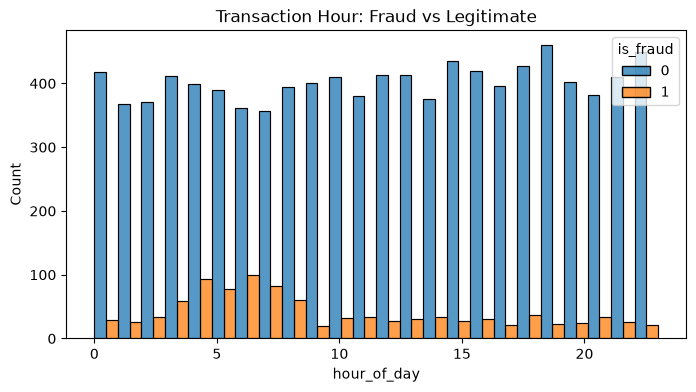

In [64]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='hour_of_day', hue='is_fraud', multiple='dodge', bins=24)
plt.title('Transaction Hour: Fraud vs Legitimate')
plt.show()

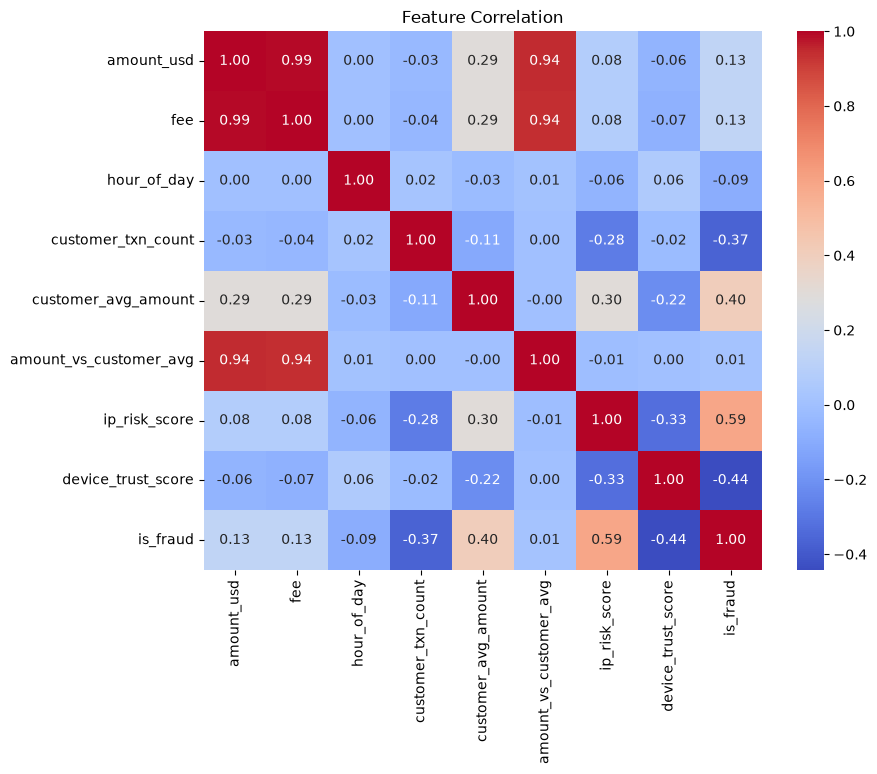

In [65]:
# correllation heat map
numeric_cols = ['amount_usd', 'fee', 'hour_of_day', 'customer_txn_count',
                'customer_avg_amount', 'amount_vs_customer_avg',
                'ip_risk_score', 'device_trust_score', 'is_fraud']

plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.show()

In [66]:
df.to_csv(r'C:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/features_transactions.csv', index=False)
print('Saved:', df.shape)

Saved: (10622, 35)


Featuree Engineering
What does this code do
1) extracts the hour, day of the week and weekend indicator from the time stamp column
2) hour shows time of the day (0-23)
3) day of the week shows whcich day it is (0 = Monday....6 = Sunday)
4) is weekend becomes one for saturday/sunday, else 0
5) the prints show the new columns and distribution of hours.


In [67]:
# extract time based features
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print('time features created')
print(df[['timestamp', 'hour_of_day', 'day_of_week', 'is_weekend']].head())
print('\nHour of Day Distribution:')
print(df['hour_of_day'].value_counts().sort_index())

time features created
                   timestamp  hour_of_day  day_of_week  is_weekend
0 2022-10-03 18:40:59.468549           18            0           0
1 2022-10-03 20:39:38.468549           20            0           0
2 2022-10-03 23:02:43.468549           23            0           0
3 2022-10-04 01:08:53.468549            1            1           0
4 2022-10-04 09:35:03.468549            9            1           0

Hour of Day Distribution:
hour_of_day
0     447
1     393
2     404
3     471
4     493
5     467
6     460
7     439
8     455
9     421
10    442
11    413
12    441
13    443
14    408
15    463
16    449
17    417
18    464
19    483
20    427
21    416
22    436
23    470
Name: count, dtype: int64


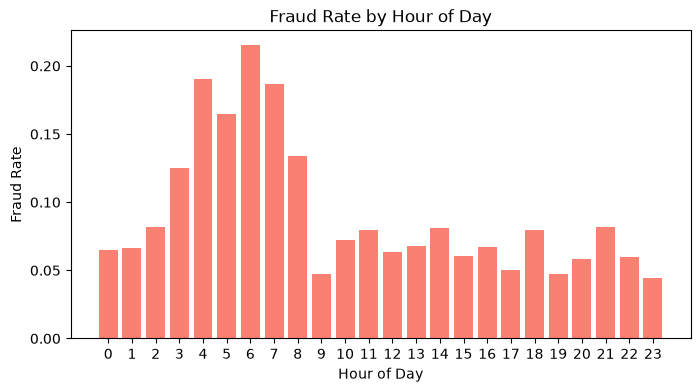

In [68]:
#fraudrate by hour
fraud_by_hour = df.groupby('hour_of_day')['is_fraud'].mean()
plt.figure(figsize=(8, 4))
plt.bar(fraud_by_hour.index, fraud_by_hour.values, color='salmon')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.xticks(range(0, 24))
plt.show()


In [69]:
df['account_age_days'].describe()

count    10622.000000
mean       392.235643
std        341.792548
min          1.000000
25%        147.000000
50%        272.000000
75%        661.000000
max       1095.000000
Name: account_age_days, dtype: float64

age_bucket
<0-30d      0.371539
31-90d      0.444712
91-180d     0.024033
181-365d    0.017191
> 1year     0.010721
Name: is_fraud, dtype: float64


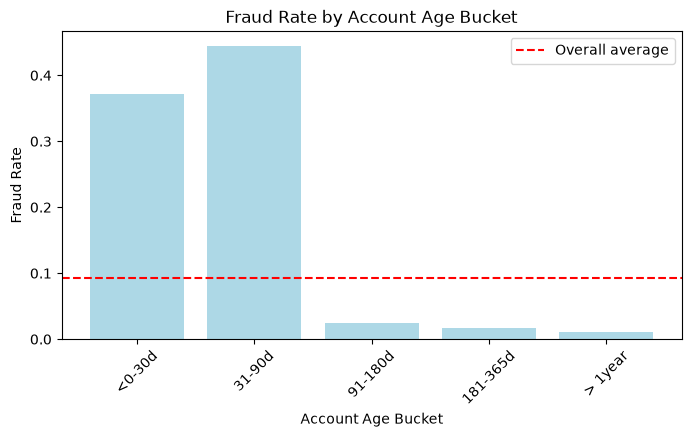

In [70]:
# fraud rateby account age date
df['age_bucket'] = pd.cut(df['account_age_days'], bins=[0, 30, 90, 180, 365, 2000],\
     labels=['<0-30d', '31-90d', '91-180d', '181-365d', '> 1year'])

fraud_by_age = df.groupby('age_bucket')['is_fraud'].mean()
print(fraud_by_age)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_age.index, fraud_by_age.values, color='lightblue')
plt.title('Fraud Rate by Account Age Bucket')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.xlabel('Account Age Bucket')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.legend()
plt.show()


txn_velocity_1h
0    0.017736
1    0.000000
2    0.000000
3    0.835878
4    0.845833
5    0.813830
6    0.708333
7    0.702703
8    0.482759
Name: is_fraud, dtype: float64


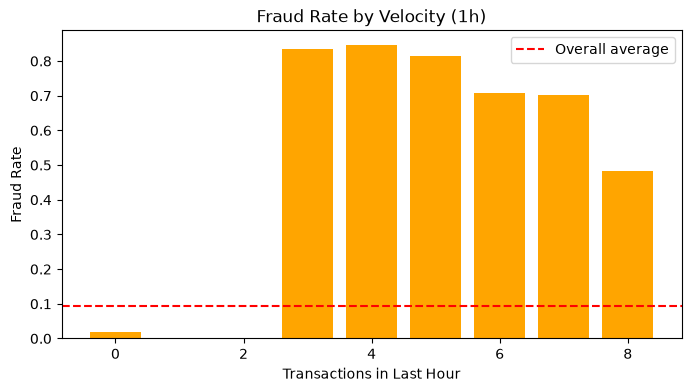

In [71]:
#fraud rate by velocity (transaction in the last hour)
fraud_by_velocity = df.groupby('txn_velocity_1h')['is_fraud'].mean()
print(fraud_by_velocity)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_velocity.index, fraud_by_velocity.values, color='orange')
plt.title('Fraud Rate by Velocity (1h)')
plt.xlabel('Transactions in Last Hour')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

amount_bucket
<$100       0.018268
$100-500    0.062540
$500-1k     0.303299
$1k-2k      0.689922
$2k-5k      0.401460
> $5k       0.166667
Name: is_fraud, dtype: float64


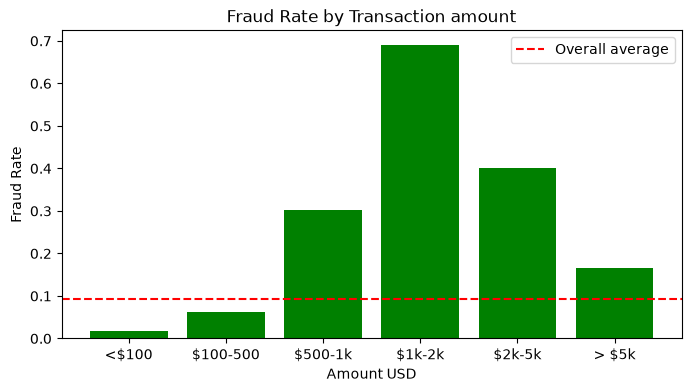

In [72]:
#fraud rate by amount  buckets
df['amount_bucket'] = pd.cut(df['amount_usd'], bins=[0, 100, 500, 1000, 2000, 10000, np.inf],\
     labels=['<$100', '$100-500', '$500-1k', '$1k-2k', '$2k-5k', '> $5k'])

fraud_by_amount = df.groupby('amount_bucket')['is_fraud'].mean()
print(fraud_by_amount)
plt.figure(figsize=(8, 4))
plt.bar(fraud_by_amount.index, fraud_by_amount.values, color='green')
plt.title('Fraud Rate by Transaction amount')
plt.xlabel('Amount USD')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()


In [73]:
# fraud rate by ip risk score buckets
df['ip_risk_score'].describe()


count    10622.000000
mean         0.384446
std          0.252456
min          0.004000
25%          0.207000
50%          0.321000
75%          0.477000
max          1.000000
Name: ip_risk_score, dtype: float64

ip_risk_bucket
Low (0-0.3)                 0.015064
(0.3-0.5)                   0.022532
(0.5-0.7)                   0.029894
 (0.7-0.8)                  0.198529
 Very Critical (0.8-1.0)    0.629268
Name: is_fraud, dtype: float64


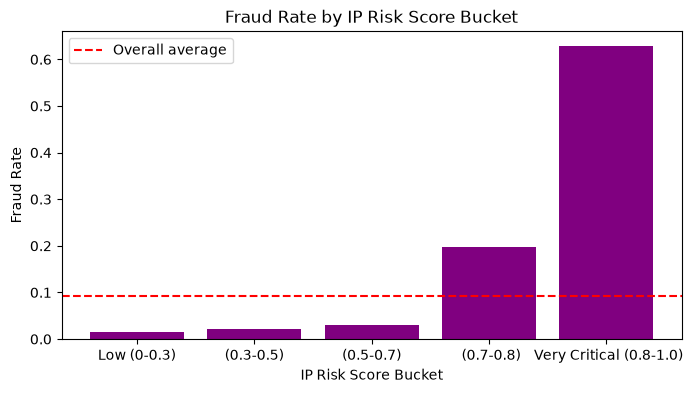

In [74]:
df['ip_risk_bucket'] = pd.cut(df['ip_risk_score'], bins=[0, 0.3, 0.5, 0.7, 0.8, 1.0],\
        labels=['Low (0-0.3)', '(0.3-0.5)', '(0.5-0.7)', ' (0.7-0.8)', ' Very Critical (0.8-1.0)'])
fraud_by_ip_risk = df.groupby('ip_risk_bucket')['is_fraud'].mean()
print(fraud_by_ip_risk)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_ip_risk.index, fraud_by_ip_risk.values, color='purple')
plt.title('Fraud Rate by IP Risk Score Bucket')
plt.xlabel('IP Risk Score Bucket')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()


device_trust_bucket
Low<0.3)      0.849791
(0.3-0.5)     0.113467
(0.5-0.7)     0.020633
 (0.7-0.8)    0.015748
 High>0.8     0.022071
Name: is_fraud, dtype: float64


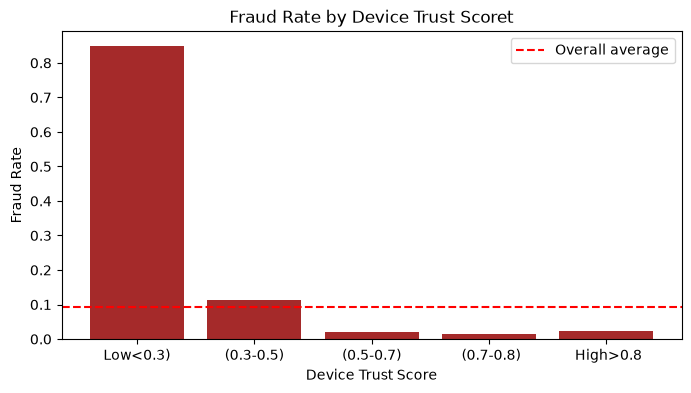

In [75]:
# fraud rate by deice trust score bucket
df['device_trust_score'].describe()
df['device_trust_bucket'] = pd.cut(df['device_trust_score'], bins=[0, 0.3, 0.5, 0.7, 0.8, 1.0],\
        labels=['Low<0.3)', '(0.3-0.5)', '(0.5-0.7)', ' (0.7-0.8)', ' High>0.8'])
fraud_by_device_trust = df.groupby('device_trust_bucket')['is_fraud'].mean()
print(fraud_by_device_trust)

plt.figure(figsize=(8, 4))
plt.bar(fraud_by_device_trust.index, fraud_by_device_trust.values, color='brown')
plt.title('Fraud Rate by Device Trust Scoret')
plt.xlabel('Device Trust Score')
plt.ylabel('Fraud Rate')
plt.axhline(df['is_fraud'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

In [76]:
#based on our analysis, create threshold-based features
df['night_hours'] = ((df['hour_of_day'] >= 3) & (df['hour_of_day'] < 7)).astype(int)
df['account_very_new'] = (df['account_age_days'] < 30).astype(int)
df['account_new'] = ((df['account_age_days'] >= 30) & (df['account_age_days'] < 90)).astype(int)
df['velocity_burst'] = (df['txn_velocity_1h'] >= 3).astype(int)
df['amount_high'] = (df['amount_usd'] > 2000).astype(int)
df['ip_risk_high'] = (df['ip_risk_score'] > 0.8).astype(int)
df['device_low'] = (df['device_trust_score'] < 0.3).astype(int)

print('features created')
print(df[['night_hours', 'account_very_new', 'account_new', 'velocity_burst',\
     'amount_high', 'ip_risk_high', 'device_low']].describe())

features created
        night_hours  account_very_new   account_new  velocity_burst  \
count  10622.000000      10622.000000  10622.000000    10622.000000   
mean       0.178027          0.169460      0.031538        0.099416   
std        0.382553          0.375175      0.174776        0.299234   
min        0.000000          0.000000      0.000000        0.000000   
25%        0.000000          0.000000      0.000000        0.000000   
50%        0.000000          0.000000      0.000000        0.000000   
75%        0.000000          0.000000      0.000000        0.000000   
max        1.000000          1.000000      1.000000        1.000000   

        amount_high  ip_risk_high    device_low  
count  10622.000000  10622.000000  10622.000000  
mean       0.028620      0.115797      0.067407  
std        0.166743      0.319997      0.250738  
min        0.000000      0.000000      0.000000  
25%        0.000000      0.000000      0.000000  
50%        0.000000      0.000000      0.00

In [77]:
df.to_csv(r'C:\Users\Opeyemi\DataScience\Fraudulent-Transaction-Detection-for-Digital-Money-Transfer/data/cleaned_transactionsV1.csv', index=False)
